Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings

Diretorio

In [3]:
# Diretórios
DATA_DIR = Path("/content")

# Carregar dados limpos
df = pd.read_csv(DATA_DIR / "df_clean.csv")

print(f"✓ Dados carregados: {df.shape[0]} linhas × {df.shape[1]} colunas")
print()

✓ Dados carregados: 3030 linhas × 20 colunas



Pergunta 1 (IAN) - Qual é o perfil geral de defasagem dos alunos?

In [4]:
print("PERGUNTA 1 (IAN): Qual é o perfil geral de defasagem dos alunos?")
print("=" * 80)

if 'IAN' in df.columns:
    print("\n Estatísticas do IAN (Indicador de Adequação ao Nível):")
    print(f"  • Média: {df['IAN'].mean():.2f}")
    print(f"  • Mediana: {df['IAN'].median():.2f}")
    print(f"  • Desvio Padrão: {df['IAN'].std():.2f}")
    print(f"  • Mínimo: {df['IAN'].min():.2f}")
    print(f"  • Máximo: {df['IAN'].max():.2f}")

    if 'ANO' in df.columns:
        print("\n Evolução do IAN por ano:")
        ian_por_ano = df.groupby('ANO')['IAN'].agg(['mean', 'median', 'std', 'count'])
        print(ian_por_ano.round(2))

        print("\n✓ Percentual de alunos adequados (IAN >= 10):")
        adequados = df.groupby('ANO').apply(lambda x: (x['IAN'] >= 10).sum() / len(x) * 100)
        for ano, pct in adequados.items():
            print(f"  • {int(ano)}: {pct:.1f}%")

    if 'ANO' in df.columns:
        grupos = [group['IAN'].dropna() for name, group in df.groupby('ANO')]
        f_stat, p_value = stats.f_oneway(*grupos)
        print(f"\n ANOVA:")
        print(f"  • F-statistic: {f_stat:.2f}")
        print(f"  • p-value: {p_value:.6f}")
        print(f"  • Significância: {'Sim' if p_value < 0.05 else 'Não'}")

print()

PERGUNTA 1 (IAN): Qual é o perfil geral de defasagem dos alunos?

 Estatísticas do IAN (Indicador de Adequação ao Nível):
  • Média: 7.18
  • Mediana: 5.00
  • Desvio Padrão: 2.54
  • Mínimo: 2.50
  • Máximo: 10.00

 Evolução do IAN por ano:
      mean  median   std  count
ANO                            
2022  6.42     5.0  2.39    860
2023  7.24     5.0  2.54   1014
2024  7.68    10.0  2.50   1156

✓ Percentual de alunos adequados (IAN >= 10):
  • 2022: 30.1%
  • 2023: 45.6%
  • 2024: 53.8%

 ANOVA:
  • F-statistic: 63.89
  • p-value: 0.000000
  • Significância: Sim



/tmp/ipykernel_279/3985058816.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  adequados = df.groupby('ANO').apply(lambda x: (x['IAN'] >= 10).sum() / len(x) * 100)


 *A média geral (7.18) indica defasagem moderada dos alunos, com grande variação entre eles (desvio 2.54).
A mediana de 5 mostra que metade dos alunos ainda está abaixo do nível adequado.
Houve melhora consistente de 2022 → 2024, tanto na média quanto no percentual de alunos adequados.
O percentual adequado subiu de 30% para 54%, sinalizando avanço educacional.
A ANOVA com p≈0 confirma que a melhora é estatisticamente significativa (não é aleatória).
O salto da mediana para 10 em 2024 sugere mudança estrutural ou intervenção relevante no sistema.

**Em resumo:**
O cenário está melhorando, mas ainda há desigualdade e bolsões importantes de defasagem.*
___________________________________

PERGUNTA 2 (IDA): O desempenho médio está melhorando?

In [6]:
print("PERGUNTA 2(IDA): O desempenho médio está melhorando?")
print("=" * 80)

if 'IDA' in df.columns:
    print("\n Estatísticas do IDA:")
    print(f"  • Média: {df['IDA'].mean():.2f}")
    print(f"  • Mediana: {df['IDA'].median():.2f}")
    print(f"  • Desvio Padrão: {df['IDA'].std():.2f}")

    if 'ANO' in df.columns:
        print("\n Evolução do IDA por ano:")
        ida_por_ano = df.groupby('ANO')['IDA'].agg(['mean', 'median', 'std', 'count'])
        print(ida_por_ano.round(2))

        print("\n Variação percentual:")
        ida_media = df.groupby('ANO')['IDA'].mean()
        for i in range(1, len(ida_media)):
            ano_anterior = ida_media.index[i-1]
            ano_atual = ida_media.index[i]
            variacao = ((ida_media.iloc[i] - ida_media.iloc[i-1]) / ida_media.iloc[i-1]) * 100
            print(f"  • {int(ano_anterior)} → {int(ano_atual)}: {variacao:+.1f}%")

print()

PERGUNTA 2(IDA): O desempenho médio está melhorando?

 Estatísticas do IDA:
  • Média: 6.38
  • Mediana: 6.60
  • Desvio Padrão: 1.90

 Evolução do IDA por ano:
      mean  median   std  count
ANO                            
2022  6.09    6.30  2.05    860
2023  6.66    6.66  1.53   1014
2024  6.35    6.50  2.04   1156

 Variação percentual:
  • 2022 → 2023: +9.4%
  • 2023 → 2024: -4.7%



*A média geral (6.38) indica desempenho intermediário dos alunos.
Mediana próxima da média sugere distribuição mais equilibrada (menos desigual que o IAN).
Houve melhora relevante de 2022 para 2023 (+9,4%), indicando avanço no desempenho.
Em 2024 ocorre leve queda (-4,7%), sinalizando possível perda de qualidade ou instabilidade.
O aumento do desvio padrão em 2024 indica maior heterogeneidade no desempenho.

**Em resumo:**
O desempenho melhorou até 2023, mas perdeu força em 2024, sugerindo que a evolução não foi sustentada. *
____________________________________

Matriz de Correlação

In [9]:
indicadores_principais = ['IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'INDE']
indicadores_disponiveis = [ind for ind in indicadores_principais if ind in df.columns]

if len(indicadores_disponiveis) > 1:
    correlation_matrix = df[indicadores_disponiveis].corr()
    print(correlation_matrix.round(3))

print()

        IAN    IDA    IEG    IAA    IPS    IPP    IPV   INDE
IAN   1.000  0.117 -0.050  0.033  0.001  0.099  0.148  0.214
IDA   0.117  1.000  0.390  0.112  0.020  0.300  0.557  0.531
IEG  -0.050  0.390  1.000  0.060 -0.078  0.191  0.424  0.385
IAA   0.033  0.112  0.060  1.000  0.164  0.048  0.056  0.125
IPS   0.001  0.020 -0.078  0.164  1.000  0.058 -0.058  0.108
IPP   0.099  0.300  0.191  0.048  0.058  1.000  0.492  0.443
IPV   0.148  0.557  0.424  0.056 -0.058  0.492  1.000  0.444
INDE  0.214  0.531  0.385  0.125  0.108  0.443  0.444  1.000



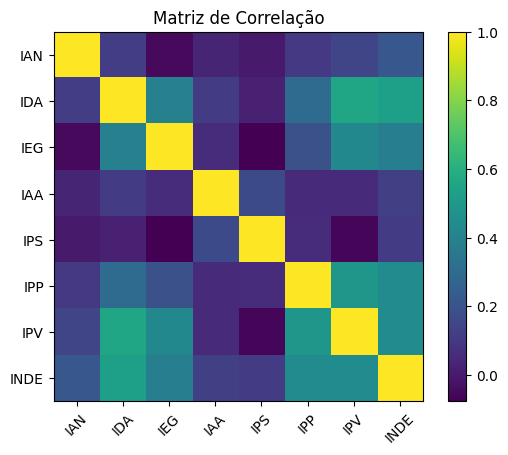

In [10]:
import matplotlib.pyplot as plt

indicadores_principais = ['IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'INDE']
indicadores_disponiveis = [ind for ind in indicadores_principais if ind in df.columns]

if len(indicadores_disponiveis) > 1:
    correlation_matrix = df[indicadores_disponiveis].corr()

    plt.imshow(correlation_matrix)
    plt.colorbar()
    plt.xticks(range(len(indicadores_disponiveis)), indicadores_disponiveis, rotation=45)
    plt.yticks(range(len(indicadores_disponiveis)), indicadores_disponiveis)
    plt.title("Matriz de Correlação")
    plt.show()

O INDE possui maior relação com IDA (0.53), IPV (0.44) e IPP (0.44), indicando que o desempenho e participação têm maior influência no indicador geral.
O IDA apresenta correlação moderada com IPV (0.56) e IEG (0.39), sugerindo que evolução e gestão pedagógica impactam o desempenho.
O IAN tem correlações fracas com os demais indicadores, indicando que a defasagem é relativamente independente das outras dimensões.
Indicadores como IAA e IPS possuem correlações baixas, mostrando menor influência sistêmica no resultado global.

-O desempenho (IDA) e participação (IPV/IPP) são os principais motores do indicador educacional geral, enquanto a defasagem (IAN) atua de forma mais isolada.